# Hyperparameter Optimization for TT Model

This notebook adapts the hyperparameter optimization functionality from "hp opt CAR coll.ipynb" to work with the new TT model dataset.

In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import xgboost as xgb
import warnings
warnings.filterwarnings("ignore")

#import plotly.express as px

In [3]:
def count_rows_in_first_column(csv_file_path):
    first_column_name = pd.read_csv(csv_file_path, nrows=0).columns[0]
    num_rows = pd.read_csv(csv_file_path, usecols=[first_column_name]).shape[0]
    print(f"First column name: {first_column_name}")
    print(f"Number of rows: {num_rows}")
    return num_rows

In [ ]:
# read an excel file which has two columns, column A has feature names, column B has READ_READY values
# and filter the feature names where READ_READY is 1
def get_feature_names_from_excel(csv_file_path):
    df = pd.read_csv(csv_file_path)
    feature_names = df[df['READ_READY'] == 'YES']['feature'].tolist()
    return feature_names

if 1 : 
    path_prefix = 
if 1:     
    path_prefix = 'E:/TomTom/SampleTomTom_PD_PCdata_columns_readready.csv'
#'/Users/Mach/dev/aps/data/2025_TT_model/joseph/SampleTomTom_PD_PCdata_columns_readready.csv'
read_feature_list = get_feature_names_from_excel(path_prefix)

FileNotFoundError: [Errno 2] No such file or directory: 'E:/TomTom/SampleTomTom_PD_PCdata_columns_readready.csv'

In [6]:
# Set path for the new dataset

# path_prefix = '/Users/Mach/dev/aps/data/2025_TT_model/joseph/'
path_prefix = 'E:/TomTom/'
#path_prefix = 'R:\Projects\TomTom\RM Test\CW 2025 JG/'

path = path_prefix
file = 'TomTom_PD_PC.csv'

#count_rows_in_first_column( path + file)



In [ ]:
READ_SAMPLE  = 0
#data_ini = pd.read_csv(path + file, index_col=0)
if READ_SAMPLE: 
    data_ini = pd.read_csv(path + file, nrows=10000, index_col=0,usecols = read_feature_list)
else:
    data_ini = pd.read_csv(path + file, index_col=0,usecols = read_feature_list)
data_train = data_ini.copy()

print(f"Dataset shape: {data_train.shape}")
display(data_train.head())

Dataset shape: (10000, 1001)


,mDrvGenMarSts,mDrvMarSts,mDrvSex,mHOPolFrm,mMultipoldisc,mNumMajViol,mNumMajinAcc,mNumMinAcc,mNumMinViol,mNumVeh,...,PC_10,PC_11,PC_12,PC_13,PC_14,PC_15,PC_16,PC_17,PC_18,PC_19
mDrvAge,,,,,,,,,,,,,,,,,,,,,
51,MS,S,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.441905,0.522322,-0.138848,-0.718932,0.688020,-0.396082,0.050889,-0.275292,-0.973286,1.016438
NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.441905,0.522322,-0.138848,-0.718932,0.688020,-0.396082,0.050889,-0.275292,-0.973286,1.016438
36,FS,S,F,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.230109,0.768948,1.472236,-0.271597,0.742080,-0.090484,0.910544,-0.952878,-0.539709,0.542526
30,MS,S,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-1.118335,-1.206527,-0.036413,-1.408566,0.426489,-0.720603,0.900948,-0.531196,-0.023618,0.139541
44,FM,M,F,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-1.406372,-3.857862,-1.620184,-2.541971,-0.394088,-0.034417,0.491426,0.160213,0.328688,-0.932510


In [4]:
#data_ini = pd.read_csv(path + file, nrows=10000, index_col=0,usecols = read_feature_list)
data_ini = pd.read_csv(path + file, index_col=0,usecols = read_feature_list)


NameError: name 'path' is not defined

In [13]:
import time

rows_to_test = [1, 5, 10, 50, 100, 500, 1000, 10000]
timings = {}

for n in rows_to_test:
    start = time.time()
    df1 = pd.read_csv(path + file, nrows = n)
    end = time.time()
    timings[n] = end - start


for n,t in timings.items():
    print(f"{n} rows: {t : .6f} seconds")


1 rows:  0.054933 seconds
5 rows:  0.060755 seconds
10 rows:  0.060801 seconds
50 rows:  0.073885 seconds
100 rows:  0.110218 seconds
500 rows:  0.300856 seconds
1000 rows:  0.585929 seconds
10000 rows:  4.524692 seconds


In [11]:
print(df1)
print(f"Time to read 1 row: {end - start : .6f} seconds")

   cc_pd_binomial datatype  lien_holder_ind_CEF mCompanyID  mDrvAge  \
0               0     TEST                 True    C147884       51   

  mDrvGenMarSts mDrvMarSts mDrvSex  mHOPolFrm  mMultipoldisc  ...     PC_19  \
0            MS          S       M        NaN            NaN  ...  1.016438   

   _WARN_  P_cc_pd_binomial1  P_cc_pd_binomial0  I_cc_pd_binomial  \
0     NaN           0.012341           0.987659                 0   

   F_cc_pd_binomial  U_cc_pd_binomial R_cc_pd_binomial1 R_cc_pd_binomial0  \
0                 0                 0         -0.012341          0.012341   

  rnd_P_cc_pd_binomial1  
0               0.01234  

[1 rows x 1941 columns]
Time to read 1 row:  0.054201 seconds


In [ ]:
if 0: 
    data_train = data_ini.copy()

In [9]:
if 1: 
    data_train.columns.to_series().to_csv(path + file[:-4]+ "data_columns.csv", index=False, header=False)

In [11]:
data_train.columns

Index(['cc_pd_binomial', 'datatype', 'lien_holder_ind_CEF', 'mCompanyID',
       'mDrvAge', 'mDrvGenMarSts', 'mDrvMarSts', 'mDrvSex', 'mHOPolFrm',
       'mMultipoldisc',
       ...
       'PC_19', '_WARN_', 'P_cc_pd_binomial1', 'P_cc_pd_binomial0',
       'I_cc_pd_binomial', 'F_cc_pd_binomial', 'U_cc_pd_binomial',
       'R_cc_pd_binomial1', 'R_cc_pd_binomial0', 'rnd_P_cc_pd_binomial1'],
      dtype='object', length=1941)

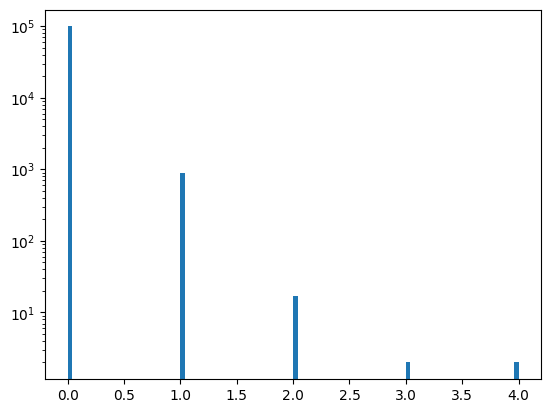

In [16]:
plt.hist(data_train['cc_pd'], bins=100, log=True);


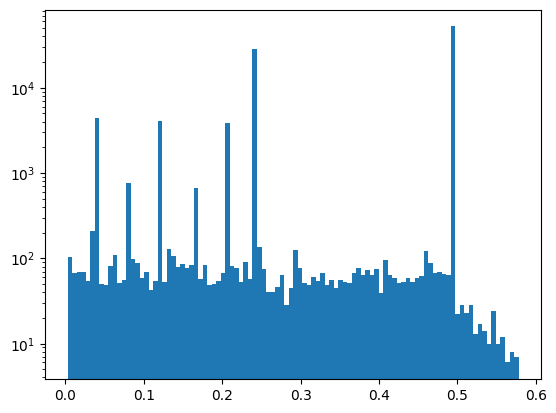

In [17]:
plt.hist(data_train['ee_pd'], bins=100, log=True);

In [ ]:
data_train['target'] = data_train['cc_pd'] 
data_train['weight'] = data_train['ee_pd'] 

data_train.drop(columns=[
'pmonth',
'termx',
'mCompanyID',
'incloss_col',
'POSTCODE',
'year',
'month',
'term',
'cc_col_capped',
'_PARTIND_' , 
'cc_col', 
'ee_col'],
inplace=True)



In [22]:
data_train.shape

(226704, 852)

In [24]:
# Modified gbm_data_prep function for the new dataset structure
def gbm_data_prep_modified(data, features, weight):
    """
    Modified version of gbm_data_prep that works with the new dataset structure.
    The new dataset already has a 'target' column instead of numerator/denominator.
    """
    facts = ['target', weight]
    #print(f"Facts: {facts}")
    #print(f"Features: {features}")
    #print(f"Weight: {weight}")
    
    agg_dict = {i: 'sum' for i in facts}
    
    #data1 = data.groupby(features, dropna=False).agg(agg_dict).reset_index()
    data1 = data.fillna(0)
    
    data1 = data1[list(features) + list(facts)]
    
    #data1 = data1.loc[data1[weight] > 0] #TODO do we need this? Maybe we do. 
    data1 = data1.loc[data1['target'].values >= 0]
    
    return data1

# Modified xbg_wrapper_hp function
def xbg_wrapper_hp_modified(train, test,features, weight, params, num_round):
    """
    Modified version of xbg_wrapper_hp that works with the new dataset structure.
    """
    d_train = gbm_data_prep_modified(train, features, weight)
    d_test = gbm_data_prep_modified(test, features, weight)
    
    weight_train = d_train[weight]
    dtrain = xgb.DMatrix(d_train.drop(columns=['target', weight]), label=d_train['target'], weight=weight_train)
    
    num_round = num_round
    global model_xgb
    model_xgb = xgb.train(params, dtrain, num_round)
    
    weight_test = d_test[weight]
    dtest = xgb.DMatrix(d_test.drop(columns=['target', weight]), label=d_test['target'])
    ypred_test = model_xgb.predict(dtest)
    
    ypred_train = model_xgb.predict(dtrain)

    def apply_predictions():
        global out_train
        global out_test
        
        out_train = d_train.copy()
        out_train['pred'] = ypred_train
        out_train['act'] = out_train['target']  # Use target directly as act
        out_train['pred_weighted'] = out_train[weight] * out_train['pred']
        out_train['act_weighted'] = out_train[weight] * out_train['act']

        out_test = d_test.copy()
        out_test['pred'] = ypred_test
        out_test['act'] = out_test['target']  # Use target directly as act
        out_test['pred_weighted'] = out_test[weight] * out_test['pred']
        out_test['act_weighted'] = out_test[weight] * out_test['act']
        
    apply_predictions()

## 5. Evaluation Functions

In [25]:
# Modified lift_chart function
def lift_chart_modified(test_data, weight_name, bins, print_table=False):
    """
    Modified version of lift_chart that works with the new dataset structure.
    """
    test_data['decile'] = (round(test_data.sort_values(by='pred', ascending=True)[weight_name].cumsum()/test_data[weight_name].sum(), 2)*bins).apply(np.floor)
    test_data['decile'] = np.where(test_data['decile'] + 1 > bins, bins, test_data['decile'] + 1)
    x = test_data.groupby(['decile'], dropna=False).agg({weight_name: 'sum', 'act_weighted': 'sum', 'pred_weighted': 'sum'}).reset_index()
    
    x['act'] = x['act_weighted']/x[weight_name]
    x['pred'] = x['pred_weighted']/x[weight_name]
    x.drop(columns=['act_weighted', 'pred_weighted'], inplace=True)
    
    dfg = x
    fig, ax = plt.subplots(figsize=(12, 6))
    ax2 = ax.twinx()
    
    y_max = np.where(dfg['act'].max() > dfg['pred'].max(), dfg['act'].max(), dfg['pred'].max())*1.20
    ax2.set_ylim(0, y_max)
    
    dfg[weight_name].plot.bar(stacked=False, ax=ax, alpha=0.6)
    dfg['act'].plot(kind='line', ax=ax2, marker='o', linewidth=0, legend='act')
    dfg['pred'].plot(kind='line', ax=ax2, marker='o', legend='pred')
    plt.show()
    
    if print_table == True:
        print(x)

# Modified model_metrics function
def model_metrics_modified(input_data, weight_name):
    """
    Modified version of model_metrics that works with the new dataset structure.
    """
    global x
    test_data = input_data.copy()
    bins = 50
    
    test_data['decile'] = (round(test_data.sort_values(by='pred', ascending=False)[weight_name].cumsum()/test_data[weight_name].sum(), 2)*bins).apply(np.floor)
    test_data['decile'] = np.where(test_data['decile'] + 1 > bins, bins, test_data['decile'] + 1)
    x = test_data.groupby(['decile'], dropna=False).agg({weight_name: 'sum', 'act_weighted': 'sum', 'pred_weighted': 'sum'}).reset_index()
    
    del test_data
    
    x['pp_act'] = x['act_weighted']/x[weight_name]
    x['pp_pred'] = x['pred_weighted']/x[weight_name]
    
    x['decile_error'] = abs(x['pp_pred']/x['pp_act'] - 1).replace(-np.inf, np.nan).replace(np.inf, np.nan).fillna(1)
    x['decile_error_sp'] = x['decile_error'] * x[weight_name]
    fit_quality = 1 - x['decile_error_sp'].sum()/x[weight_name].sum()
    
    tot_pp = x['act_weighted'].sum()/x[weight_name].sum()
    x['diff_unity'] = abs(x['pp_pred']/tot_pp - 1)
    x['diff_unity'] = x['diff_unity'] * x[weight_name]
    model_power = x['diff_unity'].sum()/x[weight_name].sum()
    
    x.drop(columns=['act_weighted', 'pred_weighted'], inplace=True)
    
    return_list = []
    return_list.append(model_power)
    return_list.append(fit_quality)
    return return_list

# Modified cv_sub_one_way function
def cv_sub_one_way_modified(weight_name, hp, val_list, features):
    """
    Modified version of cv_sub_one_way that works with the new dataset structure.
    """
    global result_temp, result_final
    result_temp = pd.DataFrame(columns=[hp, 'model_power', 'fit_quality'])
    for fold in [1, 2, 3]:
        d_tr = data_train.loc[data_train['fold'] != fold].copy()
        d_te = data_train.loc[data_train['fold'] == fold].copy()

        for val in val_list:
            if hp == 'num_round':
                xbg_wrapper_hp_modified(d_tr, d_te,features, 'weight', r1_params, val)
            else:
                new_params = r1_params.copy()
                new_params[hp] = val
                
                xbg_wrapper_hp_modified(d_tr, d_te,features, 'weight', new_params, num_round)
                
            result = pd.DataFrame(model_metrics_modified(out_test, weight_name)).T
            result.columns = (['model_power', 'fit_quality'])
            result['fit_quality'] = np.where(result['fit_quality'] < 0, 0, result['fit_quality'])  # just in case we get negatives

            result[hp] = val

            result_temp = pd.concat([result_temp, result])

            print('fold ' + str(fold) + '; ' + hp + ' = ' + str(val), end='\r')
    result_final = result_temp.groupby([hp]).agg({'model_power': 'mean', 'fit_quality': 'mean'}).reset_index()

# Function to plot hyperparameter optimization results
def hp_one_way_plot(hp, x):
    for i in ['model_power', 'fit_quality']:
        fig, ax = plt.subplots(figsize=(12, 6))
    
        y_min = x[i].min()*0.90
        y_max = x[i].max()*1.10
        ax.set_ylim(y_min, y_max)
        
        x[i].plot(kind='line', ax=ax, legend='1')

        plt.xticks(ticks=x.index, labels=x[hp])

        ax.set(title=hp)
        plt.show()

In [26]:
# Helper function to convert monotonicity constraints to XGBoost format
def xgb_mono(x):
    return str(x).replace('[','(').replace(']',')')

## 9. Initial Parameters

In [27]:
# Set initial parameters
r1_params = {
    'objective': 'reg:tweedie',
    'tweedie_variance_power': 1.5,
    'learning_rate': .05,
    'verbosity': 1,
    'max_depth': 6,
    'min_child_weight': 100,
    'subsample': 1,
    'colsample_bytree': 1,
    'alpha': 0,
    'base_score': data_train['target'].mean(),  # Use mean of target
}

num_round = 5000

## 10. Model Training and Evaluation

In [29]:
# Train a model with the initial parameters
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split
np.random.seed(42)
data_train['fold'] = np.random.randint(0, 3, size=len(data_train))
train_data = data_train.loc[data_train['fold'] != 2].copy()
test_data = data_train.loc[data_train['fold'] == 2].copy()

features = [col for col in data_train.columns if col not in ['target', 'weight']]

In [30]:
print(features)

['pyear', 'sampleSize_0', 'sampleSizeSpeedPercentile_0', 'harmonic_speed_0', 'stddev_speed_0', 'total_tt_0', 'average_speed_0', 'median_speed_0', 'speed_limit_0', 'average_tt_0', 'speed_pctl1_0', 'speed_pctl2_0', 'speed_pctl3_0', 'speed_pctl4_0', 'speed_pctl5_0', 'speed_pctl6_0', 'speed_pctl7_0', 'speed_pctl8_0', 'speed_pctl9_0', 'speed_pctl10_0', 'speed_pctl11_0', 'speed_pctl12_0', 'speed_pctl13_0', 'speed_pctl14_0', 'speed_pctl15_0', 'speed_pctl16_0', 'speed_pctl17_0', 'speed_pctl18_0', 'speed_pctl19_0', 'sampleSize_1', 'sampleSizeSpeedPercentile_1', 'harmonic_speed_1', 'stddev_speed_1', 'total_tt_1', 'average_speed_1', 'median_speed_1', 'speed_limit_1', 'average_tt_1', 'speed_pctl1_1', 'speed_pctl2_1', 'speed_pctl3_1', 'speed_pctl4_1', 'speed_pctl5_1', 'speed_pctl6_1', 'speed_pctl7_1', 'speed_pctl8_1', 'speed_pctl9_1', 'speed_pctl10_1', 'speed_pctl11_1', 'speed_pctl12_1', 'speed_pctl13_1', 'speed_pctl14_1', 'speed_pctl15_1', 'speed_pctl16_1', 'speed_pctl17_1', 'speed_pctl18_1', 'spe

In [ ]:
xbg_wrapper_hp_modified(train_data, test_data, features, 'weight', r1_params, num_round)

metrics = model_metrics_modified(out_test, 'weight')
print(f"Model power: {metrics[0]:.4f}")
print(f"Fit quality: {metrics[1]:.4f}")

In [ ]:
xbg_wrapper_hp_modified(train_data, test_data, features, 'weight', r1_params, 2000)

metrics = model_metrics_modified(out_test, 'weight')
print(f"Model power: {metrics[0]:.4f}")
print(f"Fit quality: {metrics[1]:.4f}")

In [ ]:
plt.hist(out_train['pred_weighted'] , log=True, bins=100)


In [ ]:
plt.hist(out_train['act_weighted'], log=True, bins=100)

## 11. Hyperparameter Optimization - One-Way Analysis

In [ ]:
def cv_sub_full(weight_name):
    global result_temp, result_final
    
    hplist = ['tweedie_p','lr','max_depth', 'min_child','subsample','colsample_bytree', 'alpha','num_round', 'model_power','fit_quality']
    result_temp = pd.DataFrame(columns = hplist )

    
    for fold in [1,2,3,4,5]:
        d_tr = data_train.loc[data_train['fold'] != fold].copy()
        d_te = data_train.loc[data_train['fold'] == fold].copy()
        
        new_params = {
            'objective': 'reg:tweedie',
            'tweedie_variance_power': 1.5,
            'learning_rate': .05,
            'verbosity': 1,
            'max_depth': 6,
            'min_child_weight': 100,
            'subsample': 1,
            'colsample_bytree': 1,
            'alpha': 0
            #'monotone_constraints': xgb_mono(mono_list)
        }
        
        counter = 0
        print(tweedie_p_list)
        iterations = len(tweedie_p_list) * len(learning_rate_list) * len(max_depth_list) * \
        len(min_child_weight_list) * len(subsample_list) * len(colsample_by_tree_list) * \
        len(alpha_list) * len(num_round_list)
        
        for tweedie_p in tweedie_p_list:
            for learning_rate in learning_rate_list:
                for max_depth in max_depth_list:
                    for min_child_weight in min_child_weight_list:
                        for subsample in subsample_list:
                            for colsample_by_tree in colsample_by_tree_list:
                                for alph in alpha_list:
                                    for num_round in num_round_list:
                                        counter += 1
                                        new_params['tweedie_variance_power'] = tweedie_p
                                        new_params['learning_rate'] = learning_rate
                                        new_params['max_depth'] = max_depth
                                        new_params['min_child_weight'] = min_child_weight
                                        new_params['subsample'] = subsample
                                        new_params['colsample_bytree'] = colsample_by_tree
                                        new_params['alpha'] = alph

                                        xbg_wrapper_hp_modified(d_tr,d_te,features,'weight',new_params,num_round)

                                        metrics = pd.DataFrame(model_metrics_modified(out_test, 'weight')).T
                                        #print(metrics)
                                        
                                        #result.columns = (['model_power','fit_quality'])
                                        result = pd.DataFrame(columns =   pd.DataFrame(columns = hplist ) )
                                        result['fit_quality'] = metrics[0]
                                        result['model_power'] = metrics[1]
                                        
                                        result['tweedie_variance_power'] = tweedie_p
                                        result['learning_rate'] = learning_rate
                                        result['max_depth'] = max_depth
                                        result['min_child_weight'] = min_child_weight
                                        result['subsample'] = subsample
                                        result['colsample_bytree'] = colsample_by_tree
                                        result['alpha'] = alph
                                        result['num_round'] = num_round

                                        result_temp = pd.concat([result_temp,result])
                                        result.head()

                                        print('fold ' + str(fold) + '; ' + str(counter) + '/' + str(iterations) + '                  ', end = '\r')
                                    
    groupby_list = []
    groupby_list.append('tweedie_variance_power')
    groupby_list.append('learning_rate')
    groupby_list.append('max_depth')
    groupby_list.append('min_child_weight')
    groupby_list.append('subsample')
    groupby_list.append('colsample_bytree')
    groupby_list.append('alpha')
    groupby_list.append('num_round')
    
    result_final = result_temp.groupby(groupby_list).agg({'model_power': 'mean', 'fit_quality': 'mean'}).reset_index()

In [ ]:
# cv_sub_full

tweedie_p_list = [ 1,1.2, 1.5]
learning_rate_list = [0.01, 0.1]
max_depth_list = [6, 7]
min_child_weight_list = [100]
subsample_list = [1]
colsample_by_tree_list = [1]
alpha_list = [0]
num_round_list = [100, 500]

cv_sub_full( 'weight')







In [ ]:
result_final

In [ ]:
result_save_path = '/Users/Mach/dev/aps/code/2025_TT_model/modelling/hp_opt_data/'
result_save_path_file = result_save_path + 'hp_round1_param' + '.csv'
result_final.to_csv(result_save_path_file, index=False)

In [ ]:

hover_list = ['tweedie_variance_power', 'learning_rate', 'max_depth', 'min_child_weight', 'subsample', 'colsample_bytree', 'alpha', 'num_round']
fig = px.scatter(result_final, x='model_power', y='fit_quality', hover_data = hover_list)
fig.show()

In [ ]:
train_data = data_train.loc[data_train['fold'] != 1].copy()
test_data = data_train.loc[data_train['fold'] == 1].copy()

# Set initial parameters
r1_params = {
    'objective': 'reg:tweedie',
    'tweedie_variance_power': 1.2,
    'learning_rate': .01,
    'verbosity': 1,
    'max_depth': 8,
    'min_child_weight': 100,
    
    
    'subsample': 1,
    'colsample_bytree': 1,
    'alpha': 0,
    'base_score': data_train['target'].mean(),  # Use mean of target
}

num_round = 5000
xbg_wrapper_hp_modified(train_data,test_data,features,'weight',r1_params,num_round)

In [ ]:
out_train

In [ ]:
plt.hist(out_train['pred_weighted'], bins=10, log = True)

In [ ]:
plt.hist(out_train['act_weighted'], bins=10, log = True)

In [ ]:
def lift_chart_modified_v2(test_data, weight_name, bins, print_table=True, title="Lift Chart"):
    """
    Create lift chart for model evaluation.

    test_data : DataFrame containing actual and predicted values
    weight_name : Name of the weight column
    bins : int Number of bins to use for the lift chart
    print_table : bool, default=True Whether to print the table of values
    title : str, default="Lift Chart" Title for the chart
    """
    lift_data = test_data.copy()
    lift_data = lift_data.sort_values(by='pred')
    
    lift_data['decile'] = (round(lift_data.sort_values(by='pred', ascending=True)[weight_name].cumsum()/lift_data[weight_name].sum(), 2)*bins).apply(np.floor)
    lift_data['decile'] = np.where(lift_data['decile'] + 1 > bins, bins, lift_data['decile'] + 1)
    x = lift_data.groupby(['decile'], dropna=False).agg({weight_name: 'sum', 'act_weighted': 'sum', 'pred_weighted': 'sum'}).reset_index()
    
    x['act'] = x['act_weighted']/x[weight_name]
    x['pred'] = x['pred_weighted']/x[weight_name]
    x.drop(columns=['act_weighted', 'pred_weighted'], inplace=True)
    
    dfg = x
    fig, ax = plt.subplots(figsize=(12, 6))
    ax2 = ax.twinx()
    
    y_max = np.where(dfg['act'].max() > dfg['pred'].max(), dfg['act'].max(), dfg['pred'].max())*1.20
    ax2.set_ylim(0, y_max)
    
    dfg[weight_name].plot.bar(stacked=False, ax=ax, alpha=0.6)
    dfg['act'].plot(kind='line', ax=ax2, marker='o', linewidth=0, label='Actual')
    dfg['pred'].plot(kind='line', ax=ax2, marker='x', linestyle='--', label='Predicted')
    
    plt.title(title)
    plt.legend()
    plt.show()
    
    if print_table == True:
        print(x)
        
    return x

In [ ]:
lift_chart_modified_v2(out_train, 'weight', 10, print_table=True, title="Training data Lift Chart for Model Evaluation")

In [ ]:
lift_chart_modified_v2(out_test, 'weight', 10, print_table=True, title="Testing data Lift Chart for Model Evaluation")

In [ ]:
lift_chart_modified(out_train, 'weight', 10,  print_table == True)

In [ ]:
import shap 
explainer = shap.TreeExplainer(model_xgb)
shap_values = explainer.shap_values(X)